In [1]:
from hypertiling import HyperbolicGraph, GraphKernels
from hypertiling.graphics.plot import plot_tiling
from hypertiling.kernel.GRG_util import plot_graph
import matplotlib.pyplot as plt

#define colors
palette = ["#81b29a", "#f2cc8f", "#e07a5f"]

In [15]:
G = HyperbolicGraph(4, 5, 5, kernel = "GRG")


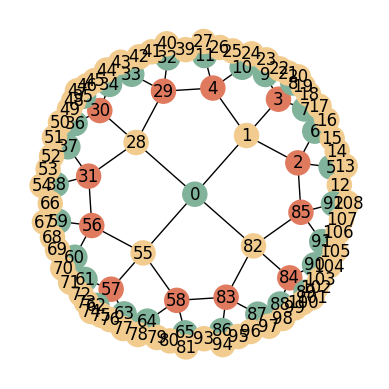

In [16]:
nbrs = G.get_nbrs_list()  # get neighbors
crds = G.center_coords    # get coordinates of cell centers
p = G.p                   # lattice parameter p

# color nodes by layer
colors = [palette[G.get_reflection_level(i) % len(palette)] for i in range(G.length)]

plot_graph(nbrs, crds, p, colors)

plt.gca().set_aspect('equal')
plt.axis("off")
plt.show()

In [6]:
print(crds)

[0.        +0.j         0.32114752+0.36459875j 0.6398322 +0.19449513j
 0.5196276 +0.58993317j 0.11217993+0.65926418j 0.84675635+0.1684033j
 0.74496202+0.39145309j 0.68204966+0.52930544j 0.60839059+0.69070579j
 0.43898383+0.74340379j 0.29429318+0.78841325j 0.06017879+0.8612401j
 0.89765352+0.0568784j  0.93406694+0.1739356j  0.88422635+0.26878565j
 0.85305411+0.34570549j 0.82006124+0.46050808j 0.77144411+0.54708425j
 0.70582009+0.62159966j 0.67309822+0.67057694j 0.64229504+0.7291975j
 0.58025533+0.75235523j 0.5275396 +0.77863349j 0.44533707+0.83432732j
 0.35331686+0.87162798j 0.23526807+0.88986658j 0.15502885+0.91108069j
 0.05464649+0.94855069j]


In [18]:
import numpy as np
import json

# Generate tiling
T = HyperbolicTiling(4, 5, 5)

# Function to calculate the angle between two points (tile center and neighbor center)
def calculate_angle(center, neighbor):
    dx = neighbor.real - center.real
    dy = neighbor.imag - center.imag
    return np.arctan2(dy, dx)

# Extract tile info with ordered neighbors
tiles_data = []
for tile in T.polygons:
    # Get tile center
    tile_center = tile.get_center()

    # Get neighbors and their centers
    neighbors = T.get_nbrs(tile.idx)
    neighbor_centers = [(T.polygons[n].get_center(), n) for n in neighbors if n is not None]

    # Sort neighbors by angle relative to the tile center
    sorted_neighbors = sorted(neighbor_centers, key=lambda x: calculate_angle(tile_center, x[0]))

    # Get ordered neighbor indices
    ordered_neighbors = [n for _, n in sorted_neighbors]

    # Store data
    tile_data = {
        "id": int(tile.idx),  # Ensure idx is a standard Python int
        "neighbors": [int(n) for n in ordered_neighbors],  # Convert all neighbor indices to int
    }
    tiles_data.append(tile_data)

# Save to JSON
with open("ordered_neighbors_tiling.json", "w") as f:
    json.dump(tiles_data, f, indent=2)


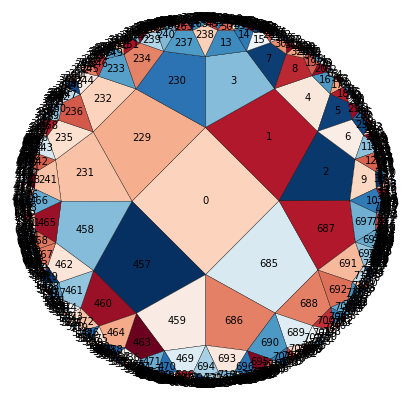

In [21]:
import matplotlib.cm as cmap
import numpy as np
from hypertiling import HyperbolicTiling
from hypertiling.graphics.plot import plot_tiling
import matplotlib.pyplot as plt
from hypertiling import HyperbolicTiling
from hypertiling.graphics.svg import *
from hypertiling.graphics.plot import plot_geodesic

colors = np.random.rand(len(T))


# Annotate tile indices
plot_tiling(T, colors, cmap=cmap.RdBu, edgecolor="k", linewidth=0.2)

# Annotate each tile with its index, using the average of its vertices
for tile in T.polygons:
    c = tile.get_center()  # complex number
    x, y = c.real, c.imag
    plt.text(x, y, str(tile.idx), ha='center', va='center', fontsize=6, color='black')

plt.axis('off')
plt.gca().set_aspect('equal')
plt.show()